
[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
--- 3.1 Descriptive Statistics ---
|                                           |     Mean |   Median |   Std Dev |    Min |     Max |   Skewness |
|:------------------------------------------|---------:|---------:|----------:|-------:|--------:|-----------:|
| Max. Demand at eve. peak (Generation end) | 11631.7  |  11589.5 |   2113.77 | 5652   | 17200   |       0.17 |
| Maximum Temperature in Dhaka was          |    31.52 |     32.5 |      4.07 |   15.4 |    40.6 |      -0.85 |
| Gas/LF limitation                         |  2382.75 |   2244.5 |   1097.87 |  267   |  5854   |       0.53 |
| Dhaka_load                                |    26.01 |      0   |     91.33 |    0   |  2002   |       8.62 |

--- 3.2 Generating Relationship Figures ---


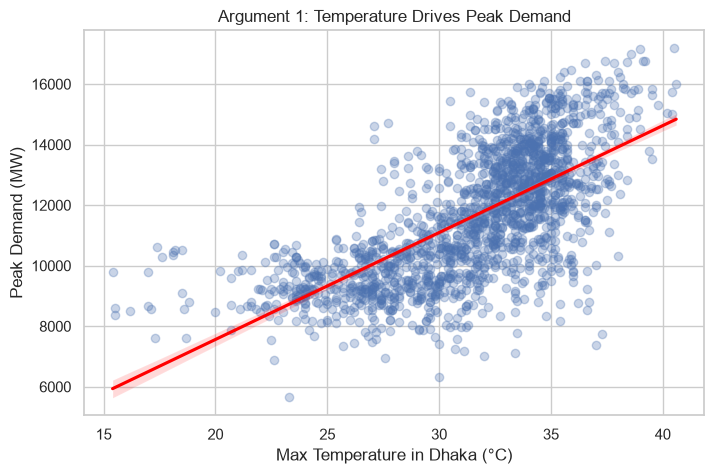

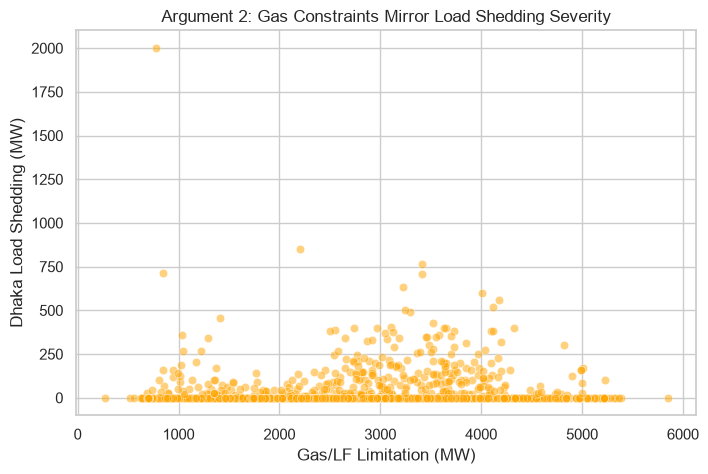


--- 3.3 Correlation with Target (For bullet points) ---
Max. Demand at eve. peak (Generation end)    1.000
Maximum Temperature in Dhaka was             0.681
Dhaka_load                                   0.356
Gas/LF limitation                           -0.007
Name: Max. Demand at eve. peak (Generation end), dtype: float64


In [7]:
#Analysis of the data so far 
%pip install tabulate

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os


os.makedirs('../figures', exist_ok=True)

# Load the dataset
df = pd.read_csv("../data/processed/clean_demand_data.csv")


target = 'Max. Demand at eve. peak (Generation end)'
key_features = [
    target,
    'Maximum Temperature in Dhaka was',
    'Gas/LF limitation',
    'Dhaka_load'
]


cols = [c for c in key_features if c in df.columns]


print("--- 3.1 Descriptive Statistics ---")
# Calculating specific metrics for central tendency, spread, and shape (skewness)
stats_df = pd.DataFrame({
    'Mean': df[cols].mean(),
    'Median': df[cols].median(),
    'Std Dev': df[cols].std(),
    'Min': df[cols].min(),
    'Max': df[cols].max(),
    'Skewness': df[cols].skew() # Positive = Right skewed, Negative = Left skewed
}).round(2)

print(stats_df.to_markdown())



print("\n--- 3.2 Generating Relationship Figures ---")
sns.set_theme(style="whitegrid")

# Figure 1: Weather driving Demand
plt.figure(figsize=(8, 5))
sns.regplot(
    data=df, 
    x='Maximum Temperature in Dhaka was', 
    y=target, 
    scatter_kws={'alpha': 0.3}, 
    line_kws={'color': 'red'}
)
plt.title('Argument 1: Temperature Drives Peak Demand')
plt.xlabel('Max Temperature in Dhaka (°C)')
plt.ylabel('Peak Demand (MW)')
plt.savefig('../figures/01_temp_vs_demand_scatter.png', bbox_inches='tight')
plt.show()

# Figure 2: Constraints driving Load Shedding
if 'Gas/LF limitation' in df.columns and 'Dhaka_load' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(
        data=df, 
        x='Gas/LF limitation', 
        y='Dhaka_load', 
        alpha=0.5,
        color='orange'
    )
    plt.title('Argument 2: Gas Constraints Mirror Load Shedding Severity')
    plt.xlabel('Gas/LF Limitation (MW)')
    plt.ylabel('Dhaka Load Shedding (MW)')
    plt.savefig('../figures/02_gas_vs_load_scatter.png', bbox_inches='tight')
    plt.show()


print("\n--- 3.3 Correlation with Target (For bullet points) ---")
correlations = df[cols].corr()[target].sort_values(ascending=False)
print(correlations.round(3))

In [8]:
#Load Data and Create Calendar features 

import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import os

# Load the clean dataset
df = pd.read_csv("../data/processed/clean_demand_data.csv")
df['Actual data of'] = pd.to_datetime(df['Actual data of'])
df.set_index('Actual data of', inplace=True)
df = df.sort_index()

target_col = 'Max. Demand at eve. peak (Generation end)'

# Calendar Features 
df['DayOfWeek'] = df.index.dayofweek
df['Month'] = df.index.month
df['IsWeekend'] = df['DayOfWeek'].isin([4, 5]).astype(int) 

# Lag Features
df['Demand_Lag1'] = df[target_col].shift(1)
df['Demand_Lag2'] = df[target_col].shift(2)
df['Demand_Lag7'] = df[target_col].shift(7)

# 7-day rolling average of demand
df['Demand_Rolling7_Mean'] = df[target_col].shift(1).rolling(window=7).mean()

# Dropping the first 7 rows since they now have NaNs from the lag calculations
df = df.dropna()
print(f"Dataset shape after creating lags: {df.shape}")

Dataset shape after creating lags: (1809, 47)


In [9]:
#Dimensionality Reduction 

# Isolate regional demand columns
regional_demand_cols = [col for col in df.columns if 'demand' in col.lower() and col != target_col]

# Standardize before PCA
scaler = StandardScaler()
scaled_regional = scaler.fit_transform(df[regional_demand_cols])

# Applying PCA and keeping only the first principla component 
pca = PCA(n_components=1) 
df['Regional_Demand_PCA'] = pca.fit_transform(scaled_regional)

variance_explained = pca.explained_variance_ratio_[0] * 100
print(f"Variance explained by 1st Principal Component: {variance_explained:.2f}%")
print("Report Note: The first PCA component captures the vast majority of regional demand variance, effectively reducing dimensionality while retaining the core demand signal.")

Variance explained by 1st Principal Component: 70.56%
Report Note: The first PCA component captures the vast majority of regional demand variance, effectively reducing dimensionality while retaining the core demand signal.


In [10]:
#Feature Selection & Export

# Keeping the target,engineered features, and the supply constraints
features_to_keep = [
    target_col,
    'DayOfWeek', 'Month', 'IsWeekend',
    'Demand_Lag1', 'Demand_Lag2', 'Demand_Lag7', 'Demand_Rolling7_Mean',
    'Gas/LF limitation', 'Coal supply Limitation', 'Low water level in Kaptai lake',
    'Regional_Demand_PCA'
]

# Keeping load columns for Question 3, if we need them for localized error analysis later
load_cols = [col for col in df.columns if 'load' in col.lower()]
final_columns = list(set(features_to_keep + load_cols))

df_featured = df[final_columns]


df_featured.to_csv("../data/processed/featured_dataset.csv")
print("Featured dataset saved successfully!")
print(f"Final feature count: {df_featured.shape[1] - 1}") # -1 for target

Featured dataset saved successfully!
Final feature count: 20
